In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("kickstarter_projects.csv")

In [2]:
# clean column State:
# remove canceled since its not really a Failedproject.
df_clean = df[df['State'].isin(['Successful', 'Failed'])]

In [3]:
# outliner removal in goal:
lower = 1
upper = df_clean['Goal'].quantile(0.99)

df_clean = df_clean[(df_clean['Goal'] >= lower) & (df_clean['Goal'] <= upper)]

# how many rows of goal are in df_clean bigger thann 3000 000?
print(f"Number of rows with goal bigger than 3000 000: {len(df_clean[df_clean['Goal'] > 3000000])}")



Number of rows with goal bigger than 3000 000: 0


In [4]:
# calculate duration of project:
df_clean['Launched'] = pd.to_datetime(df_clean['Launched'])
df_clean['Deadline'] = pd.to_datetime(df_clean['Deadline'])
df_clean['Duration'] = (df_clean['Deadline'] - df_clean['Launched']).dt.days

In [5]:
df_clean['Duration'].describe()


count    328411.000000
mean         32.893725
std          12.679732
min           0.000000
25%          29.000000
50%          29.000000
75%          35.000000
max          91.000000
Name: Duration, dtype: float64

In [6]:
print((df_clean['Duration'] == 0).sum())

88


In [7]:
df_clean = df_clean[df_clean['Duration'] > 0]

In [8]:
df_clean = df_clean.drop(columns=['ID', 'Name', 'Launched', 'Deadline', 'Pledged', 'Backers'])

df_clean.columns

Index(['Category', 'Subcategory', 'Country', 'Goal', 'State', 'Duration'], dtype='str')

In [9]:
# convert strings in state:

df_clean['State'] = df_clean['State'].map({'Successful': 1, 'Failed': 0})
df_clean['State'].value_counts()

State
0    194622
1    133701
Name: count, dtype: int64

In [10]:
print(df_clean['Category'].nunique())
print(df_clean['Subcategory'].nunique())
print(df_clean['Country'].nunique())

15
159
22


In [11]:
# One-hot-encoding: 

df_clean = pd.get_dummies(df_clean, columns=['Category', 'Subcategory', 'Country'])
print(df_clean.shape)

(328323, 199)


In [12]:
df_clean.to_csv('kickstarter_clean.csv', index=False)

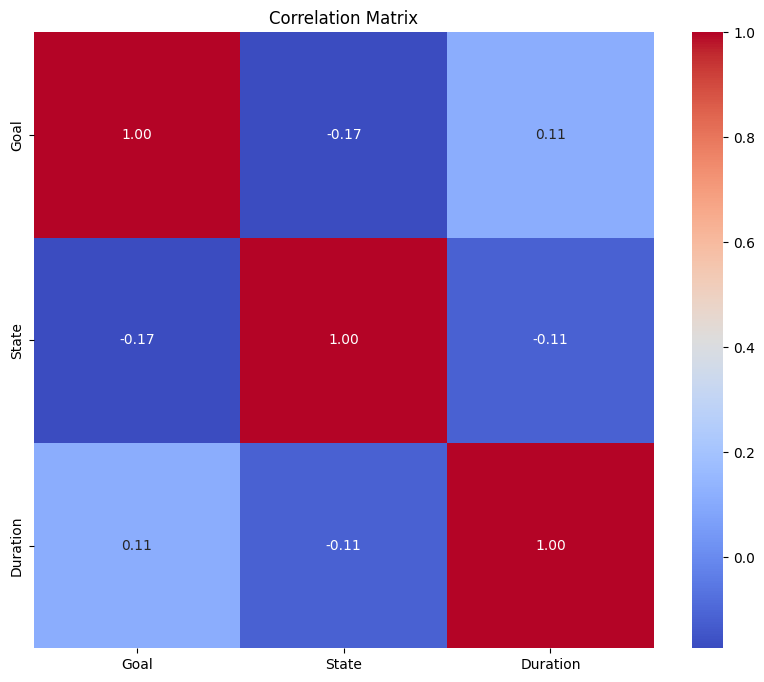

In [13]:
# EDA for df_clean:

# correlation matrix:
numeric_cols = df_clean.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()